# ⚡ EV Revolution: Market Share & Technology Trends

## 📌 Table of Contents
1. [Introduction & Sustainability Objective](#1)
2. [Data Loading & Library Imports](#2)
3. [Data Inspection (Historical Scan)](#3)
4. [Data Cleaning (Handling Categorical Nulls)](#4)
5. [Exploratory Data Analysis (EDA)](#5)
    - 5.1 [Market Leaders: Top 5 EV Manufacturers](#5.1)
    - 5.2 [Battery Electric (BEV) vs. Plug-in Hybrid (PHEV)](#5.2)
6. [Conclusion: The Future of Sustainable Transport](#6)
7. [Connection to Tableau Dashboard (Unit Chart)](#7)

# <a id="1"></a> 1. Introduction & Sustainability Objective
The global automotive industry is undergoing its most significant transformation since the invention of the internal combustion engine. This notebook analyzes the **Electric Vehicle Population Data** (specifically from Washington State) to identify key market trends.

**The Objective:** To clean and prepare categorical data for a **Unit Chart (Pictogram)** in Tableau. We aim to identify which manufacturers are leading the green revolution and which battery technologies (BEV vs. PHEV) are preferred by consumers.

# <a id="2"></a> 2. Data Loading & Library Imports
We use **Pandas** for data manipulation and **Seaborn** for high-quality statistical visualizations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style("white")

# Path: Raj Kumar Pandey version
path = '/kaggle/input/datasets/obaidhere/ev-revolution-unit-chart-analysis-of-ev-adoption/Electric_Vehicle_Population_Data.csv'
df = pd.read_csv(path)

print(f"EV Dataset Loaded! Total Records: {len(df)}")

EV Dataset Loaded! Total Records: 135038


# <a id="3"></a> 3. Data Inspection (Historical Scan)
Understanding the column structure and checking for the "health" of the data is our first priority.

In [2]:
display(df.head())
print("\n--- Column Types & Nulls ---")
display(df.info())
print("\nMissing Values Count:")
print(df.isnull().sum())

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EA0K,Thurston,Tumwater,WA,98512.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,22.0,242565116,POINT (-122.91310169999997 47.01359260000004),PUGET SOUND ENERGY INC,5.306701e+10
1,1N4BZ1DV4N,Island,Clinton,WA,98236.0,2022,NISSAN,LEAF,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,10.0,183272785,POINT (-122.35936399999997 47.97965520000008),PUGET SOUND ENERGY INC,5.302997e+10
2,5YJ3E1EA0L,Snohomish,Snohomish,WA,98290.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,0.0,44.0,112552366,POINT (-122.09150499999998 47.91555500000004),PUGET SOUND ENERGY INC,5.306105e+10
3,5YJ3E1EBXL,King,Seattle,WA,98134.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322.0,0.0,11.0,6336319,POINT (-122.32981499999994 47.579810000000066),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
4,5YJSA1CP0D,Snohomish,Edmonds,WA,98020.0,2013,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,21.0,186212960,POINT (-122.37507 47.80807000000004),PUGET SOUND ENERGY INC,5.306105e+10



--- Column Types & Nulls ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135038 entries, 0 to 135037
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         135038 non-null  object 
 1   County                                             135030 non-null  object 
 2   City                                               135030 non-null  object 
 3   State                                              135038 non-null  object 
 4   Postal Code                                        135030 non-null  float64
 5   Model Year                                         135038 non-null  int64  
 6   Make                                               135038 non-null  object 
 7   Model                                              134789 non-null  object 
 8   Electric Vehicle Type                       

None


Missing Values Count:
VIN (1-10)                                             0
County                                                 8
City                                                   8
State                                                  0
Postal Code                                            8
Model Year                                             0
Make                                                   0
Model                                                249
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         1
Base MSRP                                              1
Legislative District                                 312
DOL Vehicle ID                                         0
Vehicle Location                                      10
Electric Utility                                       8
2020 Census Tract                                      8
dtype: i

# <a id="4"></a> 4. Data Cleaning (Handling Categorical Nulls)
To ensure our visualization is accurate, we will remove records with missing 'Make' or 'Electric Vehicle Type'. We will also filter for the **Top 5 Manufacturers** to make the eventual Tableau Pictogram clean and impactful.

In [3]:
# Dropping rows with missing critical info
df = df.dropna(subset=['Make', 'Electric Vehicle Type'])

# Filtering for Top 5 Manufacturers for a focused analysis
top_5_makes = df['Make'].value_counts().head(5).index
df_filtered = df[df['Make'].isin(top_5_makes)]

print(f"Data Cleaned. Records remaining for Top 5 analysis: {len(df_filtered)}")

Data Cleaned. Records remaining for Top 5 analysis: 99187


# <a id="5"></a> 5. Exploratory Data Analysis (EDA)
In this phase, we analyze the distribution of manufacturers and the split between different electric vehicle technologies.

## <a id="5.1"></a> 5.1 Market Leaders: Top 5 EV Manufacturers
We identify the brands that have the highest number of registrations. This informs our choice of icons for the Tableau Pictogram.

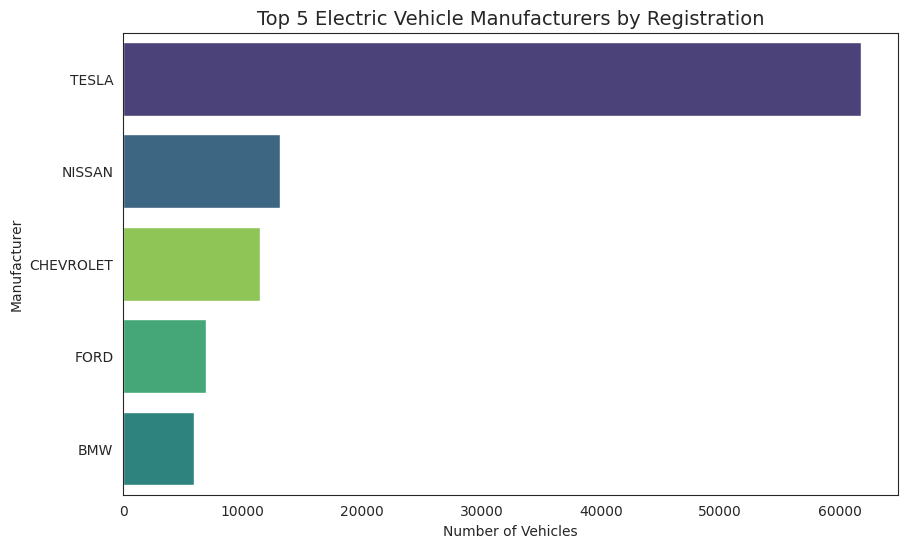

In [4]:
plt.figure(figsize=(10,6))
sns.countplot(y='Make', data=df_filtered, order=top_5_makes, palette='viridis', hue='Make', legend=False)
plt.title('Top 5 Electric Vehicle Manufacturers by Registration', fontsize=14)
plt.xlabel('Number of Vehicles')
plt.ylabel('Manufacturer')
plt.show()

## <a id="5.2"></a> 5.2 Battery Electric (BEV) vs. Plug-in Hybrid (PHEV)
Does the market prefer fully electric vehicles or hybrids? Understanding this split is crucial for urban infrastructure planning (e.g., charging stations).

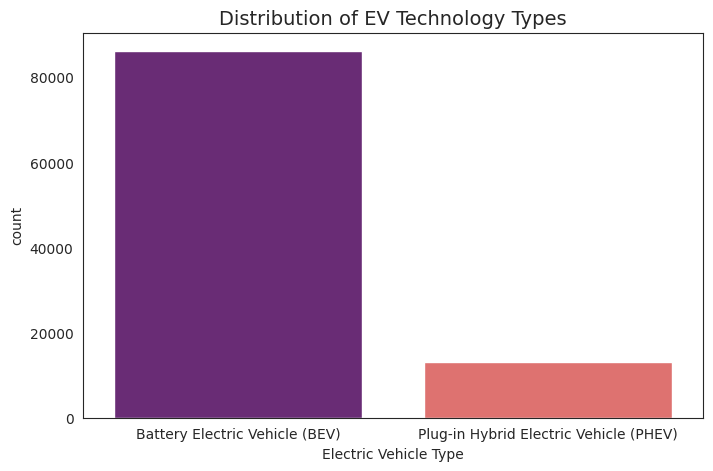

Percentage Distribution:
Electric Vehicle Type
Battery Electric Vehicle (BEV)            86.894452
Plug-in Hybrid Electric Vehicle (PHEV)    13.105548
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(8,5))
sns.countplot(x='Electric Vehicle Type', data=df_filtered, palette='magma', hue='Electric Vehicle Type', legend=False)
plt.title('Distribution of EV Technology Types', fontsize=14)
plt.show()

print("Percentage Distribution:")
print(df_filtered['Electric Vehicle Type'].value_counts(normalize=True) * 100)

# <a id="6"></a> 6. Conclusion: The Future of Sustainable Transport
1. **Tesla Dominance:** The data confirms that Tesla is the significant market leader in EV registrations.
2. **Shift to Fully Electric:** Battery Electric Vehicles (BEV) represent the majority of the population, indicating a strong consumer shift toward purely electric mobility over hybrid options.
3. **Data Preparedness:** The categorical cleaning performed here ensures that our Tableau dashboard will be free of noise and outliers.

# <a id="7"></a> 7. Connection to Tableau Dashboard (Unit Chart)
The insights and filtered data generated here serve as the source for our **Pictogram/Unit Chart in Tableau**. By representing these volumes through repetitive shapes, we make the "EV Revolution" visually tangible for stakeholders.